# Does the test control its false-positive rate?

A hypothesis test is only trustworthy if it rejects a *true* null no more often
than its nominal level. Here we check the **Type-I error** of `KLCE_test`
empirically: we generate many datasets from a **locally calibrated** model (the
null is true) and confirm that

- the p-values are approximately Uniform(0, 1), and
- the rejection rate at level 0.05 is close to 0.05.

This uses the corrected permutation p-value
`(1 + #{null >= observed}) / (1 + iterations)` (the default), which is designed to
control the Type-I error rate.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import kernel_calibration as kc

In [2]:
n_trials = 200
alpha = 0.05
pvals = []
for t in range(n_trials):
    # miscalibration=0  ->  the null (local calibration) is TRUE
    X, y, f = kc.make_calibration_data(n=400, miscalibration=0.0, seed=t)
    pw, xw = kc.select_bandwidths(X, f)
    _, p = kc.KLCE_test(X, y, f, pw, 200, key=t, x_kernel_width=xw)
    pvals.append(float(p))
pvals = np.array(pvals)

rejection_rate = float(np.mean(pvals < alpha))
print(f"{n_trials} trials under the null")
print(f"rejection rate at alpha={alpha}: {rejection_rate:.3f}  (target ~{alpha})")

200 trials under the null
rejection rate at alpha=0.05: 0.055  (target ~0.05)


## The p-value distribution should be roughly uniform

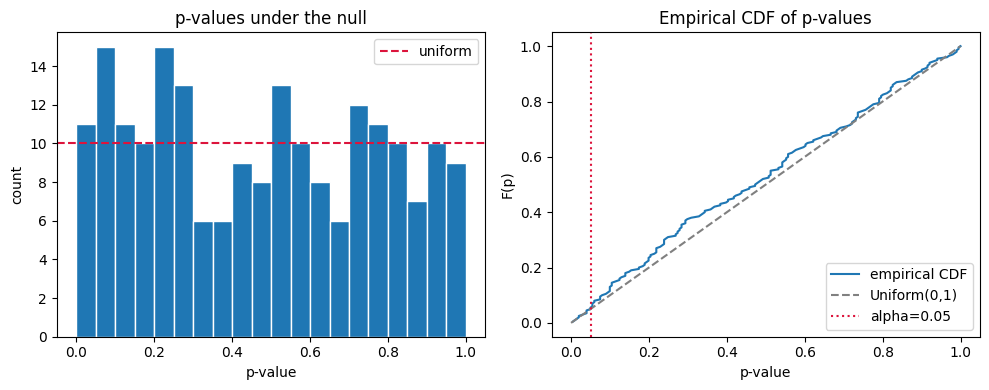

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.hist(pvals, bins=20, range=(0, 1), edgecolor="white")
ax1.axhline(n_trials / 20, color="crimson", ls="--", label="uniform")
ax1.set_xlabel("p-value")
ax1.set_ylabel("count")
ax1.set_title("p-values under the null")
ax1.legend()

# Empirical CDF vs. the uniform diagonal
xs = np.sort(pvals)
ax2.plot(xs, np.arange(1, len(xs) + 1) / len(xs), label="empirical CDF")
ax2.plot([0, 1], [0, 1], color="grey", ls="--", label="Uniform(0,1)")
ax2.axvline(alpha, color="crimson", ls=":", label=f"alpha={alpha}")
ax2.set_xlabel("p-value")
ax2.set_ylabel("F(p)")
ax2.set_title("Empirical CDF of p-values")
ax2.legend()
fig.tight_layout()
plt.show()

The p-values track the uniform diagonal and the rejection rate sits near the
nominal 0.05 — evidence that the KLCE test is well-calibrated as a test, so a
small p-value on real data is meaningful rather than an artifact.